In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

import concurrent.futures


import numpy as np
import pandas as pd
import ast
import glob
import pickle
import dask
import os
import itertools

import pickle

#from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from statsmodels.regression.rolling import RollingOLS

from tqdm.notebook import tqdm

from multiprocessing import Pool, cpu_count
from joblib import Parallel, delayed
#from tqdm import tqdm
from collections import Counter
from functools import reduce


#import dask
#import dask.dataframe as dd
#from dask.distributed import Client
#from dask.diagnostics import ProgressBar

#client = Client(n_workers=20, memory_limit="10GB", interface='lo')
from concurrent.futures import ThreadPoolExecutor

#import dask_ml.cluster as dask_cluster

from pprint import pprint
import os

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

### Load Augmented DF

In [2]:
augmented_df = pd.read_csv("../../data/augmented_us-counties_latest.csv")
augmented_df["date"] = pd.to_datetime(augmented_df["date"])
augmented_df["fips"] = augmented_df["fips"].astype(int)
augmented_df["days_from_start"] = augmented_df["days_from_start"].astype(int)
augmented_df["log_rolled_cases"] = np.log(augmented_df["rolled_cases"] + 1.1)
augmented_df = augmented_df.sort_values(by=["fips","date"])
augmented_df["shifted_log_rolled_cases"] = augmented_df.groupby("fips")["log_rolled_cases"].shift(-7)

/home/zwang937/.local/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [3]:
# Check for gaps
gt_columns = ["fips", "days_from_start", "shifted_log_rolled_cases"]
augmented_df_gt = augmented_df[gt_columns]
grouped = augmented_df_gt.groupby('fips')

for fips, group in grouped:
    missing_days = group['days_from_start'].diff().gt(1).sum()
    if missing_days > 0:
        print(f"Gap(s) found in 'days_from_start' for fips {fips}: {missing_days} gap(s)")


### Load TLGRF Benchmark Dataset

In [4]:
benchmark_TLGRF_dataset = pd.read_csv("../generate_benchmark_TLGRF_dataset/benchmark_TLGRF_dataset.csv")
benchmark_TLGRF_dataset["date"] = pd.to_datetime(benchmark_TLGRF_dataset["date"])

df = benchmark_TLGRF_dataset.copy()
fips_list = df["fips"].unique()
display(benchmark_TLGRF_dataset)

,fips,days_from_start,intercept_TLGRF,r_TLGRF,county,state,date,rolled_cases,log_rolled_cases,shifted_log_rolled_cases,TLGRF_predicted_log_rolled_cases
0,1001,69,NaN,NaN,Autauga,Alabama,2020-03-30,5.142857,1.831438,2.469309,NaN
1,1001,70,NaN,NaN,Autauga,Alabama,2020-03-31,6.000000,1.960095,2.528012,NaN
2,1001,71,NaN,NaN,Autauga,Alabama,2020-04-01,6.857143,2.074070,2.550561,NaN
3,1001,72,NaN,NaN,Autauga,Alabama,2020-04-02,7.428571,2.143422,2.625703,NaN
4,1001,73,NaN,NaN,Autauga,Alabama,2020-04-03,8.285714,2.239189,2.676117,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3390311,99999,1153,1456.032249,-0.030986,New York City,New York,2023-03-19,13972.285714,9.544910,NaN,9.328005
3390312,99999,1154,1389.214236,-0.039535,New York City,New York,2023-03-20,13317.571429,9.496922,NaN,9.220178
3390313,99999,1155,1323.021840,-0.054503,New York City,New York,2023-03-21,12458.714286,9.430264,NaN,9.048744
3390314,99999,1156,1531.624962,-0.024711,New York City,New York,2023-03-22,12154.857143,9.405575,NaN,9.232600


### Define `read_csv_file` helper

In [5]:
def read_csv_file(file_path):
    # Read the CSV file into a pandas DataFrame
    try:
        GRF_df = pd.read_csv(file_path)
        return GRF_df
    except pd.errors.EmptyDataError:
        print(file_path)

### Read Time Variant no CUSP GRF

In [6]:
directory = "./time_variant_no_CUSP_grf_results/time_variant_no_CUSP_grf_backtest_state_forests_windowsize=2_numtrees=100"
time_variant_no_CUSP_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(time_variant_no_CUSP_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    time_variant_no_CUSP_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in time_variant_no_CUSP_file_paths)
    pbar.update(len(time_variant_no_CUSP_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

Reading CSV files:   0%|          | 0/1108 [00:00<?, ?it/s]

In [7]:
time_variant_no_CUSP_GRF_results = pd.concat(time_variant_no_CUSP_GRF_dfs).sort_values(by=["fips", "days_from_start"])
time_variant_no_CUSP_GRF_results["date"] = pd.to_datetime(time_variant_no_CUSP_GRF_results["date"])
time_variant_no_CUSP_GRF_results = time_variant_no_CUSP_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
time_variant_no_CUSP_GRF_results = time_variant_no_CUSP_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])
time_variant_no_CUSP_GRF_results = pd.merge(time_variant_no_CUSP_GRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])

display(time_variant_no_CUSP_GRF_results)

,fips,date,county,state,days_from_start,rolled_cases,log_rolled_cases,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,20.285714,3.062723,-0.000060,3.062306,3.133629
1,1001,2020-04-17,Autauga,Alabama,87,20.714286,3.082565,-0.000766,3.077205,3.170286
2,1001,2020-04-18,Autauga,Alabama,88,20.714286,3.082565,-0.001080,3.075004,3.205646
3,1001,2020-04-19,Autauga,Alabama,89,21.000000,3.095578,-0.000760,3.090260,3.228543
4,1001,2020-04-20,Autauga,Alabama,90,21.428571,3.114784,-0.005826,3.074003,3.256447
...,...,...,...,...,...,...,...,...,...,...
2649546,99999,2023-03-19,New York City,New York,1153,13972.285714,9.544910,-0.004858,9.510901,NaN
2649547,99999,2023-03-20,New York City,New York,1154,13317.571429,9.496922,-0.005695,9.457056,NaN
2649548,99999,2023-03-21,New York City,New York,1155,12458.714286,9.430264,-0.011651,9.348704,NaN
2649549,99999,2023-03-22,New York City,New York,1156,12154.857143,9.405575,-0.006065,9.363121,NaN


### Read Time Variant GRF

In [8]:
directory = "./time_variant_grf_results/time_variant_grf_backtest_state_forests_windowsize=2_numtrees=100"
time_variant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(time_variant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    time_variant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in time_variant_file_paths)
    pbar.update(len(time_variant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

Reading CSV files:   0%|          | 0/1110 [00:00<?, ?it/s]

In [9]:
time_variant_GRF_results = pd.concat(time_variant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
time_variant_GRF_results["date"] = pd.to_datetime(time_variant_GRF_results["date"])
time_variant_GRF_results = time_variant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
time_variant_GRF_results = time_variant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])
time_variant_GRF_results = pd.merge(time_variant_GRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
time_variant_GRF_results.to_csv("time_variant_GRF_results_df.csv", index=False)

display(time_variant_GRF_results)

,fips,date,county,state,days_from_start,rolled_cases,log_rolled_cases,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,20.285714,3.062723,0.014734,3.165860,3.133629
1,1001,2020-04-17,Autauga,Alabama,87,20.714286,3.082565,-0.010749,3.007321,3.170286
2,1001,2020-04-18,Autauga,Alabama,88,20.714286,3.082565,-0.008377,3.023923,3.205646
3,1001,2020-04-19,Autauga,Alabama,89,21.000000,3.095578,0.003237,3.118235,3.228543
4,1001,2020-04-20,Autauga,Alabama,90,21.428571,3.114784,0.018454,3.243964,3.256447
...,...,...,...,...,...,...,...,...,...,...
2649553,99999,2023-03-19,New York City,New York,1153,13972.285714,9.544910,-0.000178,9.543666,NaN
2649554,99999,2023-03-20,New York City,New York,1154,13317.571429,9.496922,-0.000654,9.492346,NaN
2649555,99999,2023-03-21,New York City,New York,1155,12458.714286,9.430264,-0.000224,9.428695,NaN
2649556,99999,2023-03-22,New York City,New York,1156,12154.857143,9.405575,0.000129,9.406476,NaN


In [10]:
directory = "./shifted_W_time_variant_grf_results/time_variant_grf_backtest_state_forests_windowsize=2_numtrees=100"
shifted_W_time_variant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(shifted_W_time_variant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    shifted_W_time_variant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in shifted_W_time_variant_file_paths)
    pbar.update(len(shifted_W_time_variant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

Reading CSV files:   0%|          | 0/1110 [00:00<?, ?it/s]

In [11]:
shifted_W_time_variant_GRF_results = pd.concat(shifted_W_time_variant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
shifted_W_time_variant_GRF_results["date"] = pd.to_datetime(shifted_W_time_variant_GRF_results["date"])
shifted_W_time_variant_GRF_results = shifted_W_time_variant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
shifted_W_time_variant_GRF_results = shifted_W_time_variant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])
shifted_W_time_variant_GRF_results = pd.merge(shifted_W_time_variant_GRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])

shifted_W_time_variant_GRF_results.to_csv("shifted_W_time_variant_GRF_results_df.csv", index=False)

display(shifted_W_time_variant_GRF_results)

,fips,date,county,state,days_from_start,rolled_cases,log_rolled_cases,shifted_days_from_start,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,20.285714,3.062723,0,0.029451,3.268881,3.133629
1,1001,2020-04-17,Autauga,Alabama,87,20.714286,3.082565,1,0.033634,3.318004,3.170286
2,1001,2020-04-18,Autauga,Alabama,88,20.714286,3.082565,2,0.028902,3.284877,3.205646
3,1001,2020-04-19,Autauga,Alabama,89,21.000000,3.095578,3,0.025175,3.271800,3.228543
4,1001,2020-04-20,Autauga,Alabama,90,21.428571,3.114784,4,0.023614,3.280084,3.256447
...,...,...,...,...,...,...,...,...,...,...,...
2649553,99999,2023-03-19,New York City,New York,1153,13972.285714,9.544910,1103,-0.009829,9.476110,NaN
2649554,99999,2023-03-20,New York City,New York,1154,13317.571429,9.496922,1104,-0.004860,9.462904,NaN
2649555,99999,2023-03-21,New York City,New York,1155,12458.714286,9.430264,1105,-0.002493,9.412810,NaN
2649556,99999,2023-03-22,New York City,New York,1156,12154.857143,9.405575,1106,-0.003673,9.379860,NaN


### Read Time Invariant GRF

In [12]:
directory = "./time_invariant_grf_results/time_invariant_grf_backtest_state_forests_windowsize=2_numtrees=100"
time_invariant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(time_invariant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    time_invariant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in time_invariant_file_paths)
    pbar.update(len(time_invariant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

Reading CSV files:   0%|          | 0/1110 [00:00<?, ?it/s]

In [13]:
time_invariant_GRF_results = pd.concat(time_invariant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
time_invariant_GRF_results["date"] = pd.to_datetime(time_invariant_GRF_results["date"])
time_invariant_GRF_results = time_invariant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
time_invariant_GRF_results = time_invariant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])

time_invariant_GRF_results = pd.merge(time_invariant_GRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])

time_invariant_GRF_results.to_csv("time_invariant_GRF_results_df.csv",index=False)

display(time_invariant_GRF_results)

,fips,date,county,state,days_from_start,log_rolled_cases,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,3.062723,0.075195,3.589089,3.133629
1,1001,2020-04-17,Autauga,Alabama,87,3.082565,0.064403,3.533383,3.170286
2,1001,2020-04-18,Autauga,Alabama,88,3.082565,0.053266,3.455429,3.205646
3,1001,2020-04-19,Autauga,Alabama,89,3.095578,0.056698,3.492464,3.228543
4,1001,2020-04-20,Autauga,Alabama,90,3.114784,0.055530,3.503493,3.256447
...,...,...,...,...,...,...,...,...,...
2649553,99999,2023-03-19,New York City,New York,1153,9.544910,0.001367,9.554478,NaN
2649554,99999,2023-03-20,New York City,New York,1154,9.496922,0.001389,9.506648,NaN
2649555,99999,2023-03-21,New York City,New York,1155,9.430264,0.001364,9.439815,NaN
2649556,99999,2023-03-22,New York City,New York,1156,9.405575,0.001365,9.415132,NaN


In [14]:
directory = "./shifted_W_time_invariant_grf_results/time_invariant_grf_backtest_state_forests_windowsize=2_numtrees=100"
shifted_W_time_invariant_file_paths = [os.path.join(directory, file) for file in os.listdir(directory) if file.endswith(".csv")]
with tqdm(total=len(shifted_W_time_invariant_file_paths), desc="Reading CSV files") as pbar:
    # Define the function for reading CSV files
    # Read the CSV files in parallel
    shifted_W_time_invariant_GRF_dfs = Parallel(n_jobs=-1)(delayed(read_csv_file)(file_path) for file_path in shifted_W_time_invariant_file_paths)
    pbar.update(len(shifted_W_time_invariant_file_paths))  # Manually update the progress bar
# Close the progress bar
pbar.close()

Reading CSV files:   0%|          | 0/1110 [00:00<?, ?it/s]

In [15]:
shifted_W_time_invariant_GRF_results = pd.concat(shifted_W_time_invariant_GRF_dfs).sort_values(by=["fips", "days_from_start"])
shifted_W_time_invariant_GRF_results["date"] = pd.to_datetime(shifted_W_time_invariant_GRF_results["date"])
shifted_W_time_invariant_GRF_results = shifted_W_time_invariant_GRF_results.rename(columns={"predicted_log_rolled_cases_GRF":"GRF_predicted_log_rolled_cases"})
shifted_W_time_invariant_GRF_results = shifted_W_time_invariant_GRF_results.dropna(subset=["GRF_predicted_log_rolled_cases"])

shifted_W_time_invariant_GRF_results = pd.merge(shifted_W_time_invariant_GRF_results, augmented_df_gt, on=["fips","days_from_start"], how="left")
#time_invariant_GRF_results = time_invariant_GRF_results.drop(columns=["predicted.grf.future", "predicted.grf.future.0", "Predicted_Double_Days"])
shifted_W_time_invariant_GRF_results.to_csv("shifted_W_time_invariant_GRF_results_df.csv", index=False)
display(shifted_W_time_invariant_GRF_results)


,fips,date,county,state,days_from_start,log_rolled_cases,shifted_days_from_start,r_GRF,GRF_predicted_log_rolled_cases,shifted_log_rolled_cases
0,1001,2020-04-16,Autauga,Alabama,86,3.062723,0,0.088425,3.681699,3.133629
1,1001,2020-04-17,Autauga,Alabama,87,3.082565,1,0.081830,3.655375,3.170286
2,1001,2020-04-18,Autauga,Alabama,88,3.082565,2,0.083574,3.667585,3.205646
3,1001,2020-04-19,Autauga,Alabama,89,3.095578,3,0.075670,3.625265,3.228543
4,1001,2020-04-20,Autauga,Alabama,90,3.114784,4,0.069887,3.603995,3.256447
...,...,...,...,...,...,...,...,...,...,...
2649553,99999,2023-03-19,New York City,New York,1153,9.544910,1103,0.001397,9.554692,NaN
2649554,99999,2023-03-20,New York City,New York,1154,9.496922,1104,0.001370,9.506510,NaN
2649555,99999,2023-03-21,New York City,New York,1155,9.430264,1105,0.001407,9.440112,NaN
2649556,99999,2023-03-22,New York City,New York,1156,9.405575,1106,0.001395,9.415341,NaN


### Compute RMSE and MAE

In [16]:
rmse_GRF_func = lambda x: np.sqrt(np.nanmean((x["GRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_GRF_func = lambda x: np.nanmean(np.abs(x["GRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))
rmse_TLGRF_func = lambda x: np.sqrt(np.nanmean((x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
mae_TLGRF_func = lambda x: np.nanmean(np.abs(x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))
#

log_20 = np.log(20 + 1.1)

TLGRF_df = benchmark_TLGRF_dataset[benchmark_TLGRF_dataset["log_rolled_cases"] >= log_20]
TLGRF_df = TLGRF_df[TLGRF_df["date"] <= "2022-12-31"]


time_invariant_GRF_df = time_invariant_GRF_results[time_invariant_GRF_results["log_rolled_cases"] >= log_20]
time_invariant_GRF_df = time_invariant_GRF_df[time_invariant_GRF_df["date"] <= "2022-12-31"]

time_variant_GRF_df = time_variant_GRF_results[time_variant_GRF_results["log_rolled_cases"] >= log_20]
time_variant_GRF_df = time_variant_GRF_df[time_variant_GRF_df["date"] <= "2022-12-31"]

time_variant_no_CUSP_GRF_df = time_variant_no_CUSP_GRF_results[time_variant_no_CUSP_GRF_results["log_rolled_cases"] >= log_20]
time_variant_no_CUSP_GRF_df = time_variant_no_CUSP_GRF_df[time_variant_no_CUSP_GRF_df["date"] <= "2022-12-31"]



shifted_W_time_invariant_GRF_df = shifted_W_time_invariant_GRF_results[shifted_W_time_invariant_GRF_results["log_rolled_cases"] >= log_20]
shifted_W_time_invariant_GRF_df = shifted_W_time_invariant_GRF_df[shifted_W_time_invariant_GRF_df["date"] <= "2022-12-31"]

shifted_W_time_variant_GRF_df = shifted_W_time_variant_GRF_results[shifted_W_time_variant_GRF_results["log_rolled_cases"] >= log_20]
shifted_W_time_variant_GRF_df = shifted_W_time_variant_GRF_df[shifted_W_time_variant_GRF_df["date"] <= "2022-12-31"]



#TLGRF
RMSE_TLGRF = TLGRF_df.groupby("date").apply(rmse_TLGRF_func)
MAE_TLGRF = TLGRF_df.groupby("date").apply(mae_TLGRF_func)
#Time Invariant GRF
RMSE_time_invariant_GRF_df = time_invariant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_time_invariant_GRF_df = time_invariant_GRF_df.groupby("date").apply(mae_GRF_func)
#Time Variant GRF
RMSE_time_variant_GRF_df = time_variant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_time_variant_GRF_df = time_variant_GRF_df.groupby("date").apply(mae_GRF_func)
#Time Variant no CUSP GRF
RMSE_time_variant_no_CUSP_GRF_df = time_variant_no_CUSP_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_time_variant_no_CUSP_GRF_df = time_variant_no_CUSP_GRF_df.groupby("date").apply(mae_GRF_func)



# Shifted W Time Invariant
RMSE_shifted_W_time_invariant_GRF_df = shifted_W_time_invariant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_shifted_W_time_invariant_GRF_df = shifted_W_time_invariant_GRF_df.groupby("date").apply(mae_GRF_func)
# Shifted W Time Variant GRF
RMSE_shifted_W_time_variant_GRF_df = shifted_W_time_variant_GRF_df.groupby("date").apply(rmse_GRF_func)
MAE_shifted_W_time_variant_GRF_df = shifted_W_time_variant_GRF_df.groupby("date").apply(mae_GRF_func)



/tmp/ipykernel_466089/2731941856.py:3: RuntimeWarning: Mean of empty slice
  rmse_TLGRF_func = lambda x: np.sqrt(np.nanmean((x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]) ** 2))
/tmp/ipykernel_466089/2731941856.py:4: RuntimeWarning: Mean of empty slice
  mae_TLGRF_func = lambda x: np.nanmean(np.abs(x["TLGRF_predicted_log_rolled_cases"] - x["shifted_log_rolled_cases"]))


In [17]:
combined_daily_metrics_df = pd.DataFrame()
combined_daily_metrics_df["MAE TLGRF"] = MAE_TLGRF
combined_daily_metrics_df["RMSE TLGRF"] = RMSE_TLGRF
combined_daily_metrics_df["MAE Time Invariant GRF"] = MAE_time_invariant_GRF_df
combined_daily_metrics_df["RMSE Time Invariant GRF"] = RMSE_time_invariant_GRF_df
combined_daily_metrics_df["MAE Time Variant GRF"] = MAE_shifted_W_time_variant_GRF_df
combined_daily_metrics_df["RMSE Time Variant GRF"] = RMSE_shifted_W_time_variant_GRF_df
combined_daily_metrics_df["MAE Time Variant no CUSP GRF"] = MAE_time_variant_no_CUSP_GRF_df
combined_daily_metrics_df["RMSE Time Variant no CUSP GRF"] = RMSE_time_variant_no_CUSP_GRF_df


combined_daily_metrics_df.to_csv("combined_GRF_daily_metrics.csv" ,index=True)

In [18]:
combined_daily_metrics_df

,MAE TLGRF,RMSE TLGRF,MAE Time Invariant GRF,RMSE Time Invariant GRF,MAE Time Variant GRF,RMSE Time Variant GRF,MAE Time Variant no CUSP GRF,RMSE Time Variant no CUSP GRF
date,,,,,,,,
2020-03-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-03-09,NaN,NaN,1.714197,1.731205,0.725362,0.764690,NaN,NaN
2020-03-10,NaN,NaN,0.727919,0.752460,0.632006,0.660122,NaN,NaN
...,...,...,...,...,...,...,...,...
2022-12-27,0.199477,0.263357,0.160055,0.211790,0.160116,0.212317,0.153975,0.206249
2022-12-28,0.130100,0.181111,0.151535,0.205063,0.150774,0.204351,0.145312,0.199807
2022-12-29,0.112732,0.174124,0.141289,0.194381,0.141267,0.194620,0.141560,0.195474


In [19]:
metrics_comparison_df = pd.DataFrame()

metrics_comparison_df["MAE"] = [MAE_time_invariant_GRF_df.median(), MAE_shifted_W_time_variant_GRF_df.median(), MAE_time_variant_no_CUSP_GRF_df.median(), MAE_TLGRF.median()]
metrics_comparison_df["RMSE"] = [RMSE_time_invariant_GRF_df.median(), RMSE_shifted_W_time_variant_GRF_df.median(), RMSE_time_variant_no_CUSP_GRF_df.median(), RMSE_TLGRF.median()]
metrics_comparison_df.index = ["Time Invariant GRF", "Time Variant GRF", "Time Variant GRF no CUSP", "TLGRF"]
metrics_comparison_df

,MAE,RMSE
Time Invariant GRF,0.218432,0.291404
Time Variant GRF,0.203763,0.275078
Time Variant GRF no CUSP,0.201207,0.274402
TLGRF,0.126516,0.194870


In [20]:
[RMSE_time_invariant_GRF_df.median(), RMSE_TLGRF.median()]

[0.29140357390349897, 0.19487029059240693]

In [21]:
[MAE_time_invariant_GRF_df.median(), MAE_TLGRF.median()]

[0.21843200300015087, 0.1265164490059572]

In [22]:
days_to_date_df = time_variant_GRF_results[["days_from_start","date"]]
days_to_date_df.drop_duplicates(inplace=True)
days_to_date_df = days_to_date_df.sort_values(by="date")

date0 = days_to_date_df["date"].min() - pd.Timedelta(days=days_to_date_df["days_from_start"].min())
date0 = date0.date()
missing_days_df = pd.DataFrame({'days_from_start': range(0, days_to_date_df["days_from_start"].max()),
                                'date': pd.date_range(start=date0, periods=days_to_date_df["days_from_start"].max())})
#date0, days_to_date_df["date"].min(), pd.Timedelta(days=days_to_date_df["days_from_start"].min())
missing_days_df

/tmp/ipykernel_466089/597084418.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  days_to_date_df.drop_duplicates(inplace=True)


,days_from_start,date
0,0,2020-01-21
1,1,2020-01-22
2,2,2020-01-23
3,3,2020-01-24
4,4,2020-01-25
...,...,...
1152,1152,2023-03-18
1153,1153,2023-03-19
1154,1154,2023-03-20
1155,1155,2023-03-21


In [23]:
days_to_date_df[days_to_date_df["date"]=="2021-09-12"]

,days_from_start,date
514,600,2021-09-12


### Plot TLGRF vs GRF

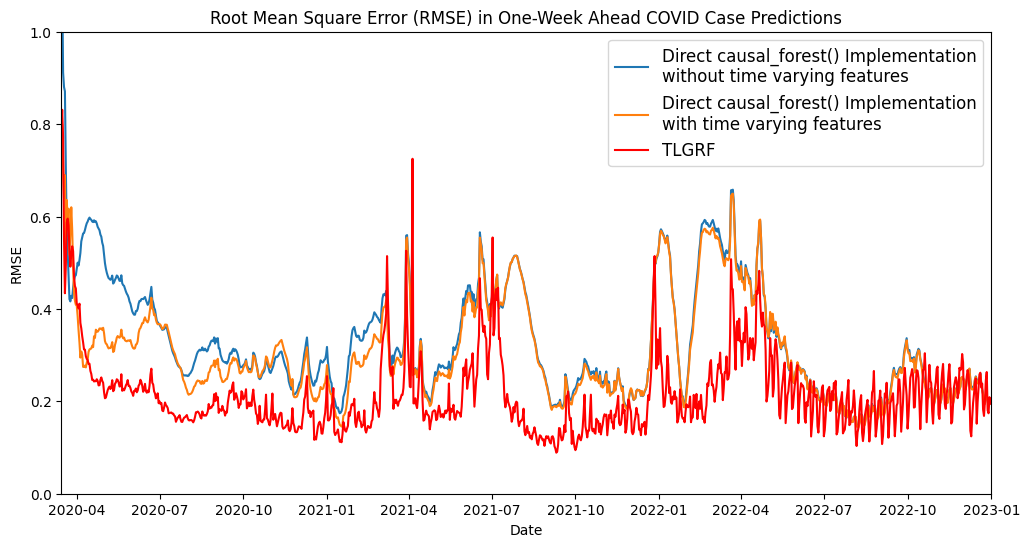

In [38]:
plt.figure(figsize=(12,6))

#plt.plot(tcv_performance_df["rmse"], label="tcv")
#plt.plot(ctcv_performance_df["rmse"], label="ctcv")
#plt.plot(RMSE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
#plt.plot(RMSE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
plt.plot(RMSE_time_invariant_GRF_df, label="Direct causal_forest() Implementation\nwithout time varying features")
plt.plot(RMSE_shifted_W_time_variant_GRF_df, label="Direct causal_forest() Implementation\nwith time varying features")
#plt.plot(RMSE_time_variant_no_CUSP_GRF_df, label="Time Variant no CUSP GRF")
plt.plot(RMSE_TLGRF, label="TLGRF", color="red")

plt.legend(loc='upper right', fontsize='large')  # Adjust the bbox_to_anchor to increase the size
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("Root Mean Square Error (RMSE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,1.0)
plt.savefig("variant_and_invariant_grf_tlgrf_rmse.png")
plt.show()


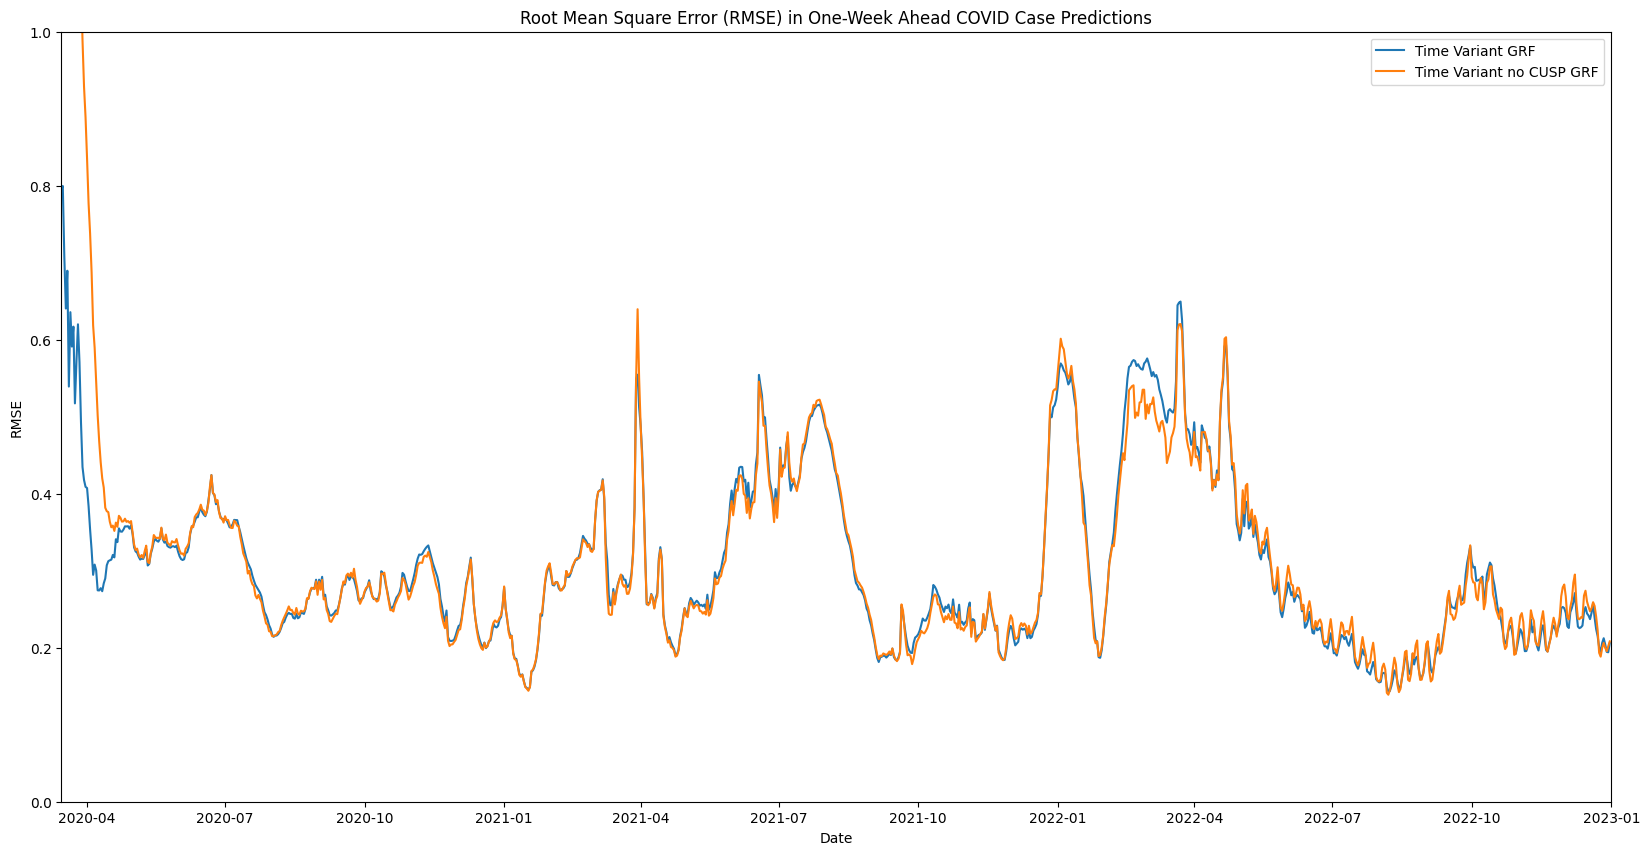

In [25]:
plt.figure(figsize=(20,10))

plt.plot(RMSE_shifted_W_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(RMSE_time_variant_no_CUSP_GRF_df, label="Time Variant no CUSP GRF")
#plt.plot(RMSE_TLGRF, label="TLGRF", color="red")

plt.legend()
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("Root Mean Square Error (RMSE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,1.0)
plt.savefig("GRF_time_variant_cusp_vs_no_cusp_rmse.png")
plt.show()


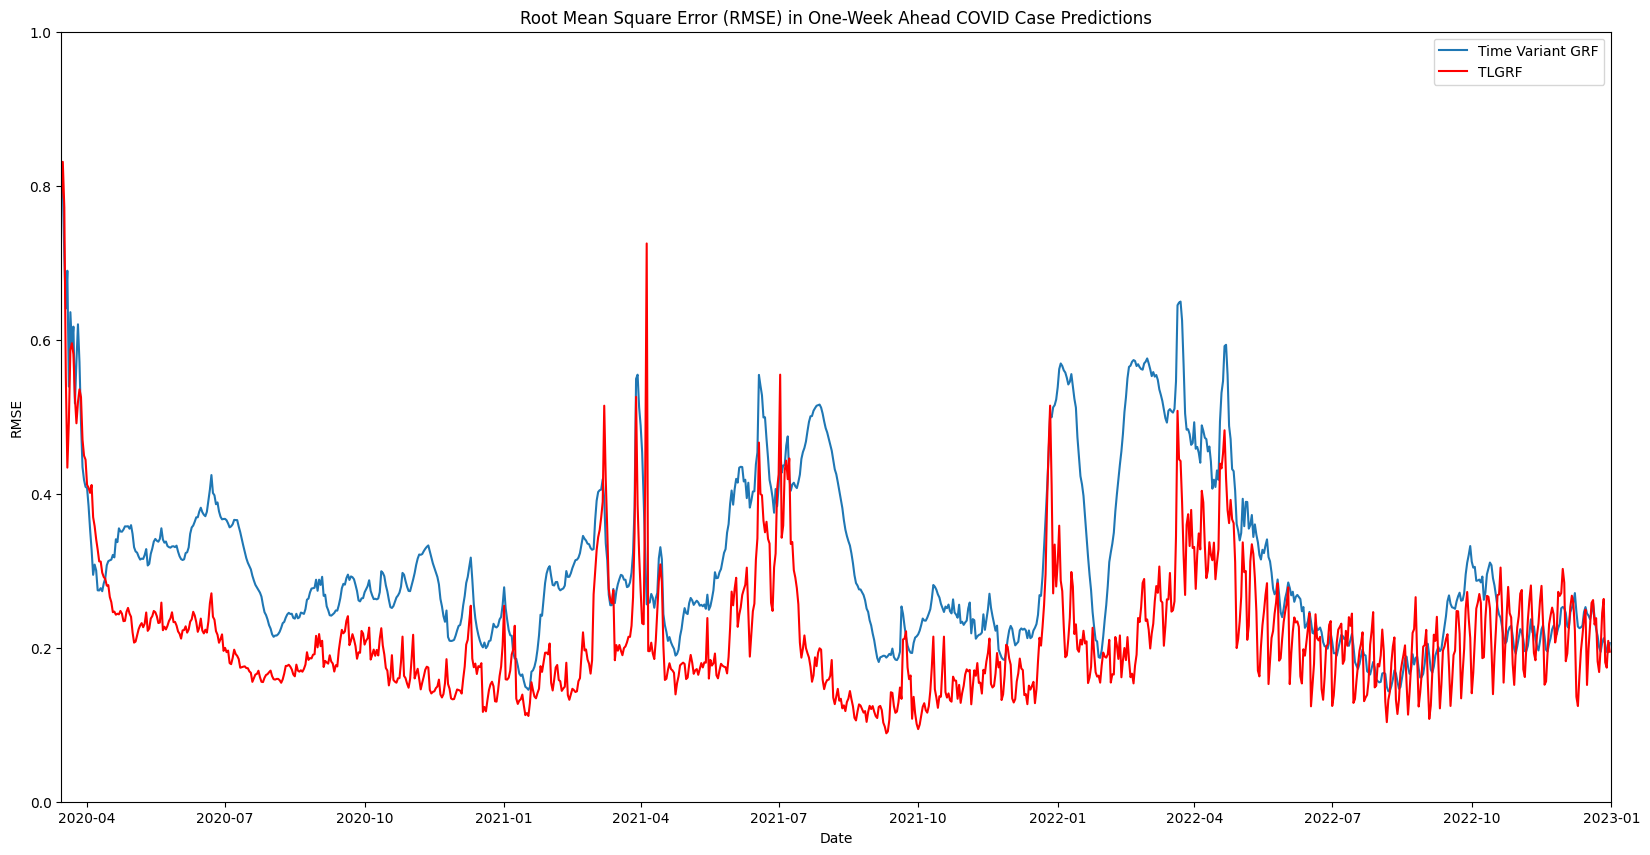

In [26]:
plt.figure(figsize=(20,10))

plt.plot(RMSE_shifted_W_time_variant_GRF_df, label="Time Variant GRF")
#plt.plot(RMSE_time_variant_no_CUSP_GRF_df, label="Time Variant no CUSP GRF")
plt.plot(RMSE_TLGRF, label="TLGRF", color="red")

plt.legend()
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("Root Mean Square Error (RMSE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,1.0)
plt.savefig("GRF_time_variant_vs_TLGRF_rmse.png")
plt.show()


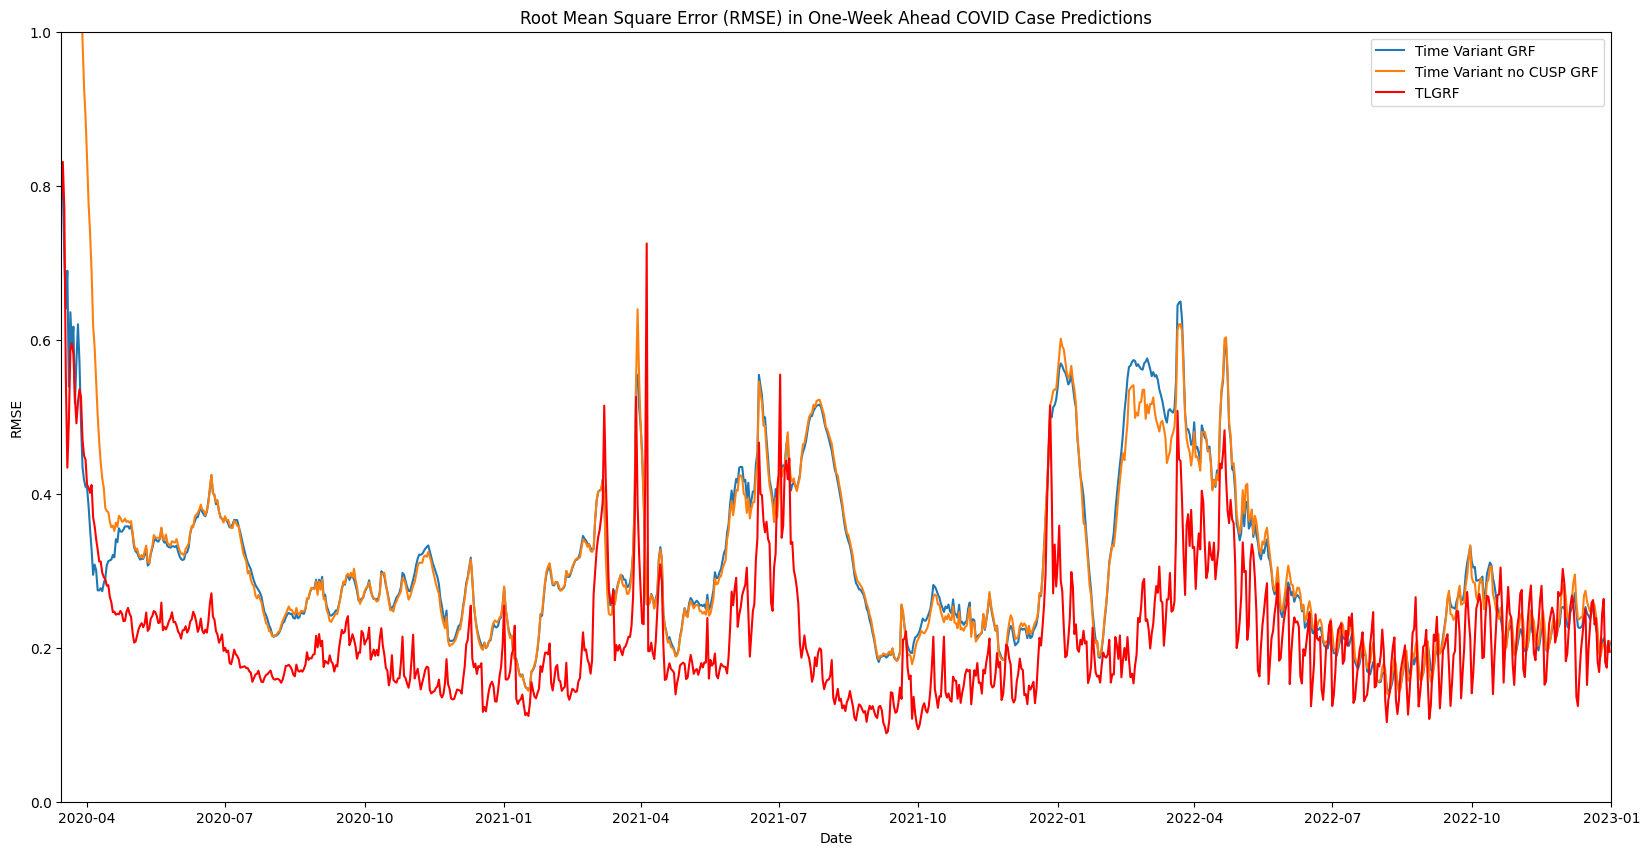

In [27]:
plt.figure(figsize=(20,10))

plt.plot(RMSE_shifted_W_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(RMSE_time_variant_no_CUSP_GRF_df, label="Time Variant no CUSP GRF")
plt.plot(RMSE_TLGRF, label="TLGRF", color="red")

plt.legend()
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("Root Mean Square Error (RMSE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,1.0)
plt.savefig("GRF_time_variant_CUSP_vs_no_CUSP_vs_TLGRF_rmse.png")
plt.show()

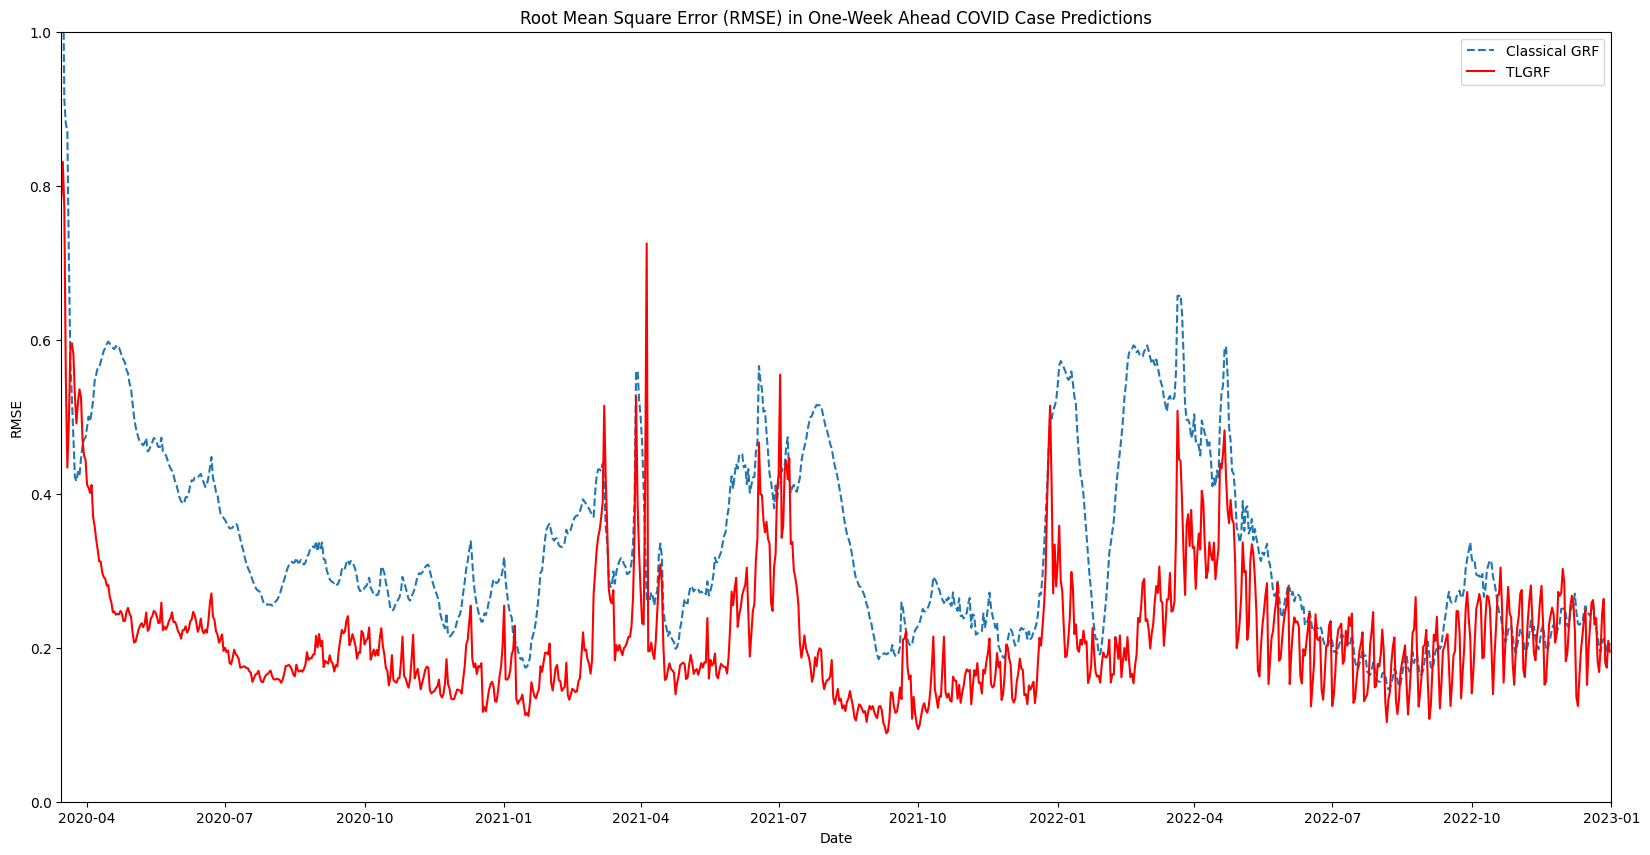

In [28]:
plt.figure(figsize=(20,10))

#plt.plot(tcv_performance_df["rmse"], label="tcv")
#plt.plot(ctcv_performance_df["rmse"], label="ctcv")
#plt.plot(RMSE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
#plt.plot(RMSE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
plt.plot(RMSE_time_invariant_GRF_df, label="Classical GRF", linestyle="dashed")
#plt.plot(RMSE_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(RMSE_TLGRF, label="TLGRF", color="red")

plt.legend()
plt.xlabel("Date")
plt.ylabel("RMSE")
plt.title("Root Mean Square Error (RMSE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,1.0)
plt.savefig("updated_grf_tlgrf_rmse.png")
plt.show()


### MAE

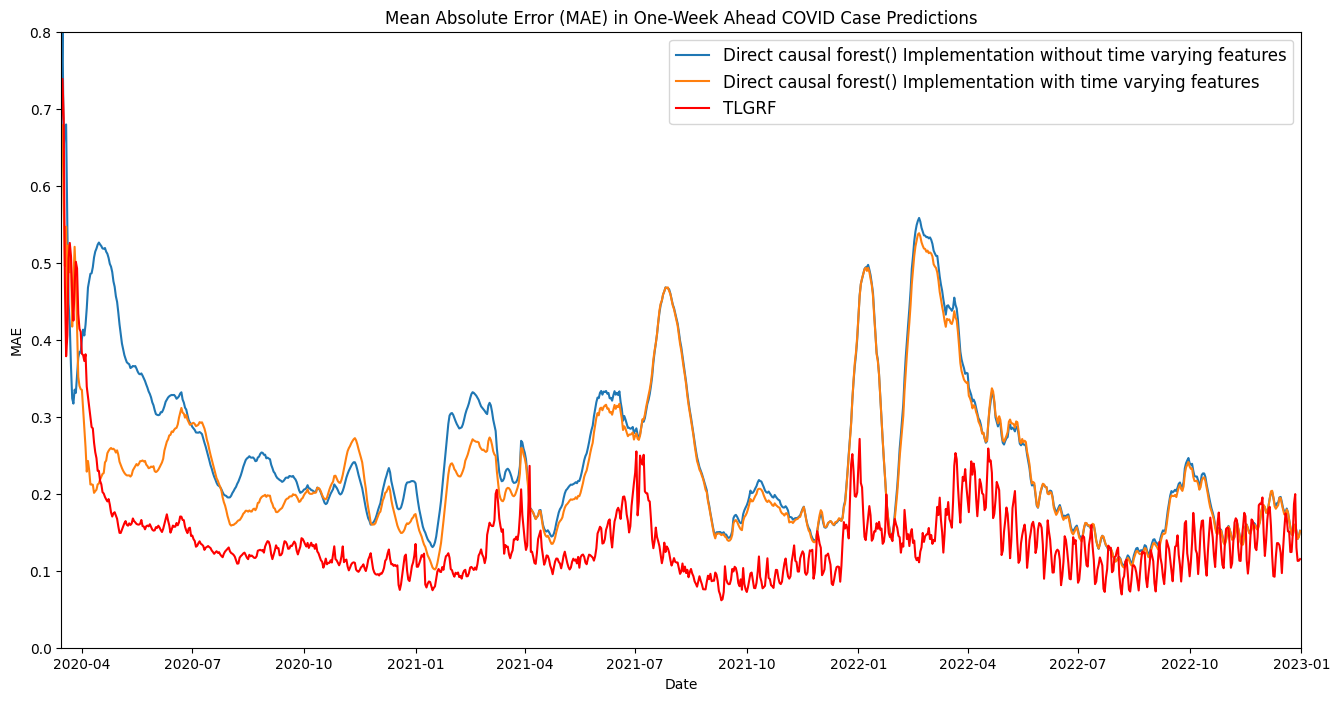

In [36]:
plt.figure(figsize=(16,8))

plt.plot(MAE_time_invariant_GRF_df, label="Direct causal_forest() Implementation\nwithout time varying features")
plt.plot(MAE_shifted_W_time_variant_GRF_df, label="Direct causal_forest() Implementation\nwith time varying features")
#plt.plot(MAE_time_variant_no_CUSP_GRF_df, label="Time Variant GRF")

plt.plot(MAE_TLGRF, label="TLGRF", color="r")

plt.legend(loc='upper right', fontsize='large')  # Adjust the bbox_to_anchor to increase the size
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("Mean Absolute Error (MAE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.8)
plt.savefig("variant_and_invariant_grf_tlgrf_mae.png")

plt.show()

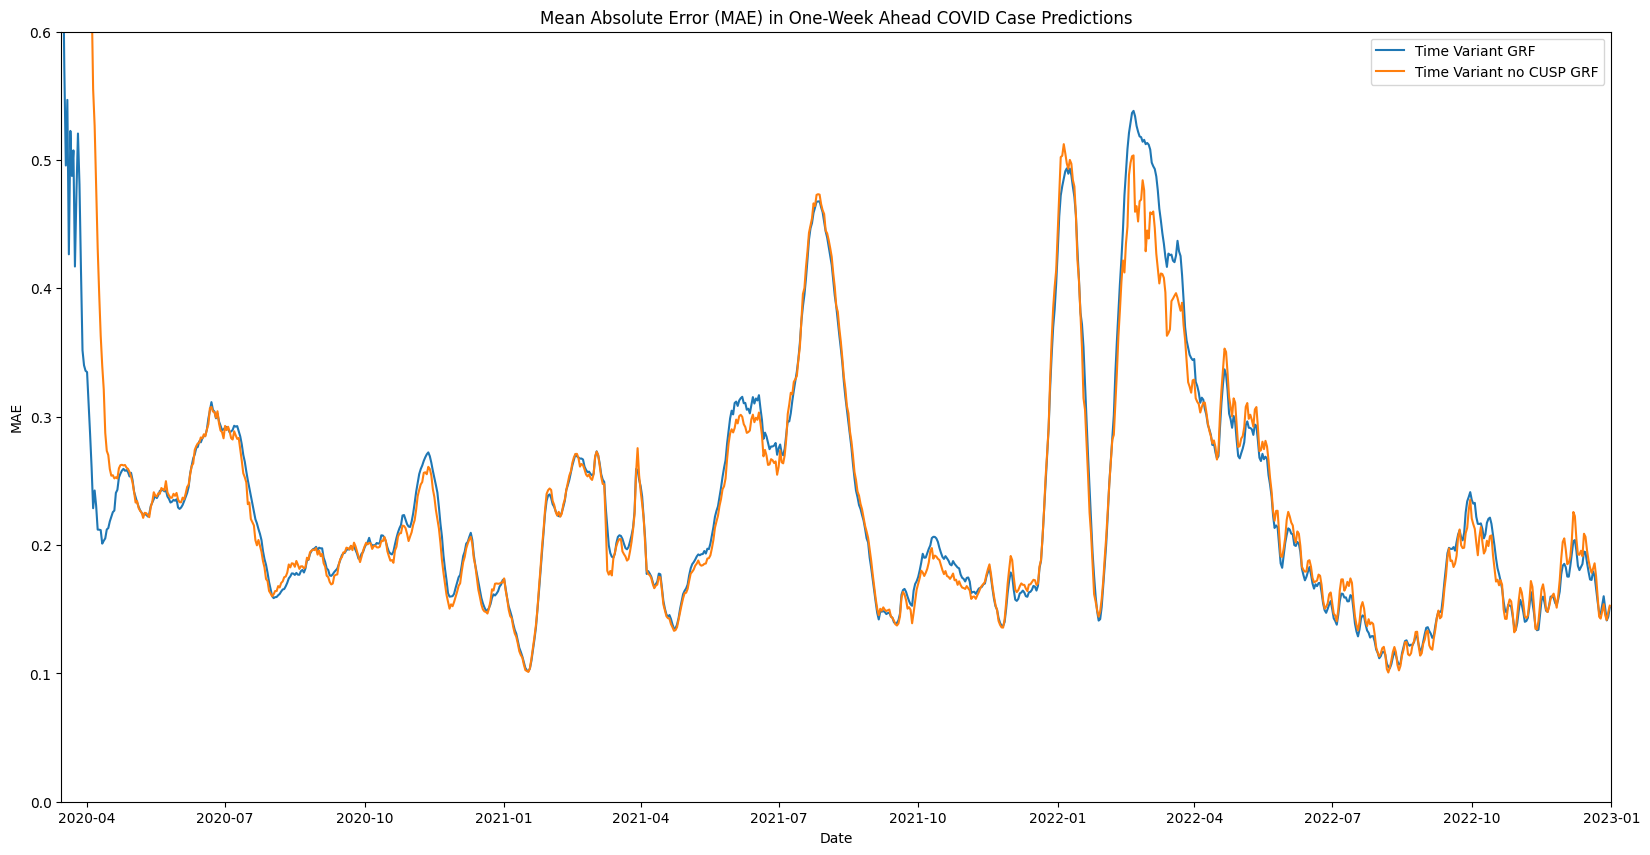

In [30]:
plt.figure(figsize=(20,10))

#plt.plot(tcv_performance_df["mae"], label="tcv")
#plt.plot(ctcv_performance_df["mae"], label="ctcv")
#plt.plot(MAE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
#plt.plot(MAE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
plt.plot(MAE_shifted_W_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(MAE_time_variant_no_CUSP_GRF_df, label="Time Variant no CUSP GRF")

plt.legend()
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("Mean Absolute Error (MAE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.6)
plt.savefig("GRF_time_variant_cusp_vs_no_cusp_mae.png")

plt.show()

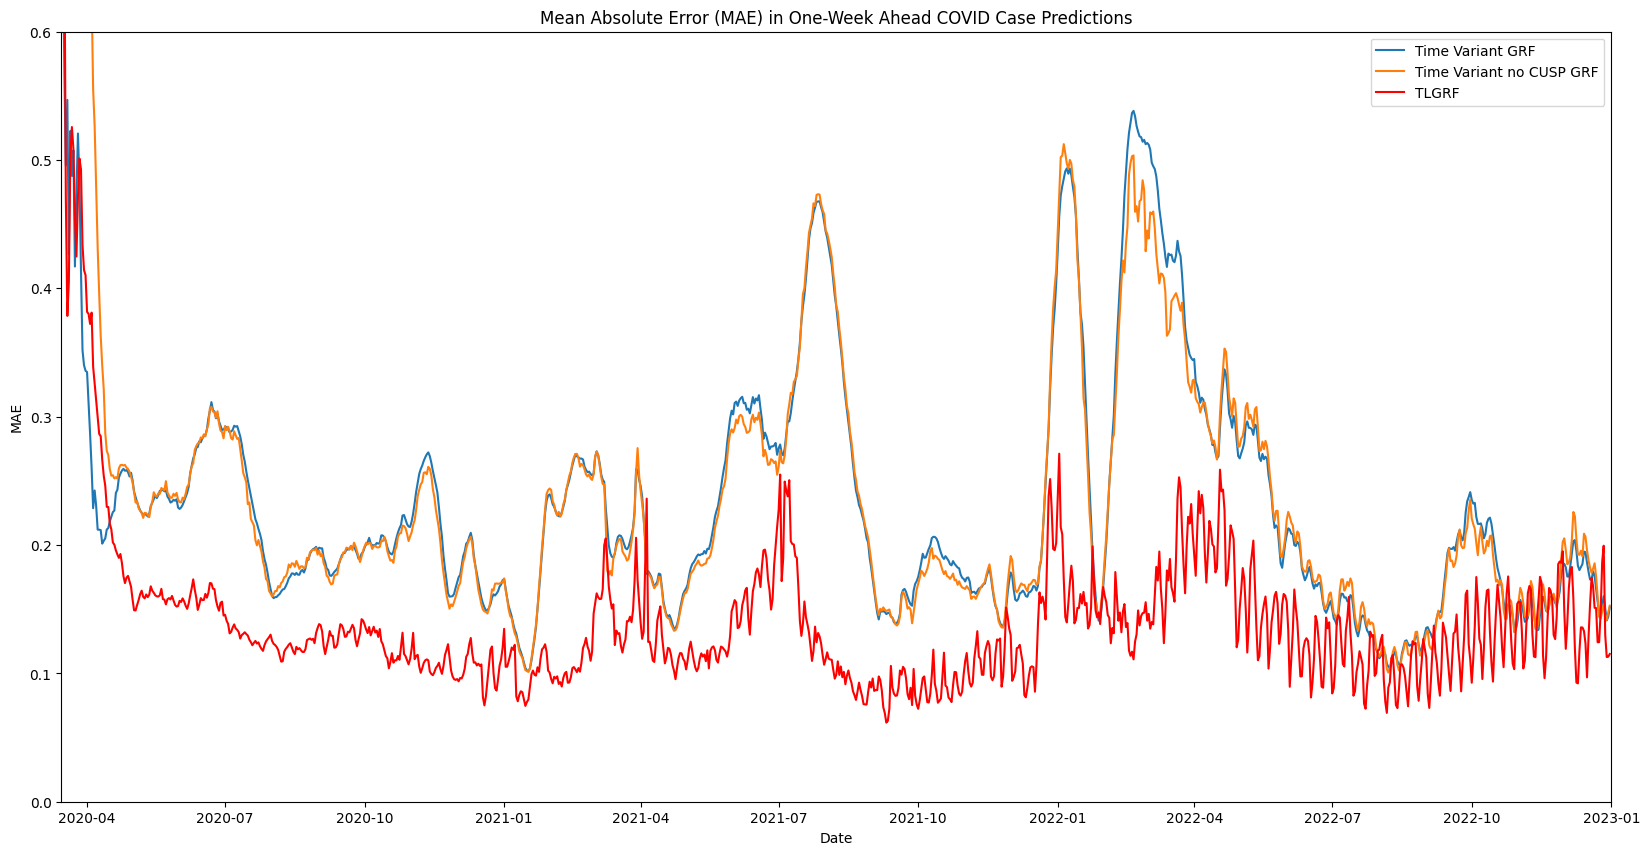

In [31]:
plt.figure(figsize=(20,10))

plt.plot(MAE_shifted_W_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(MAE_time_variant_no_CUSP_GRF_df, label="Time Variant no CUSP GRF")
plt.plot(MAE_TLGRF, label="TLGRF", color="red")

plt.legend()
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("Mean Absolute Error (MAE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.6)
plt.savefig("GRF_time_variant_CUSP_vs_no_CUSP_vs_TLGRF_mae.png")
plt.show()

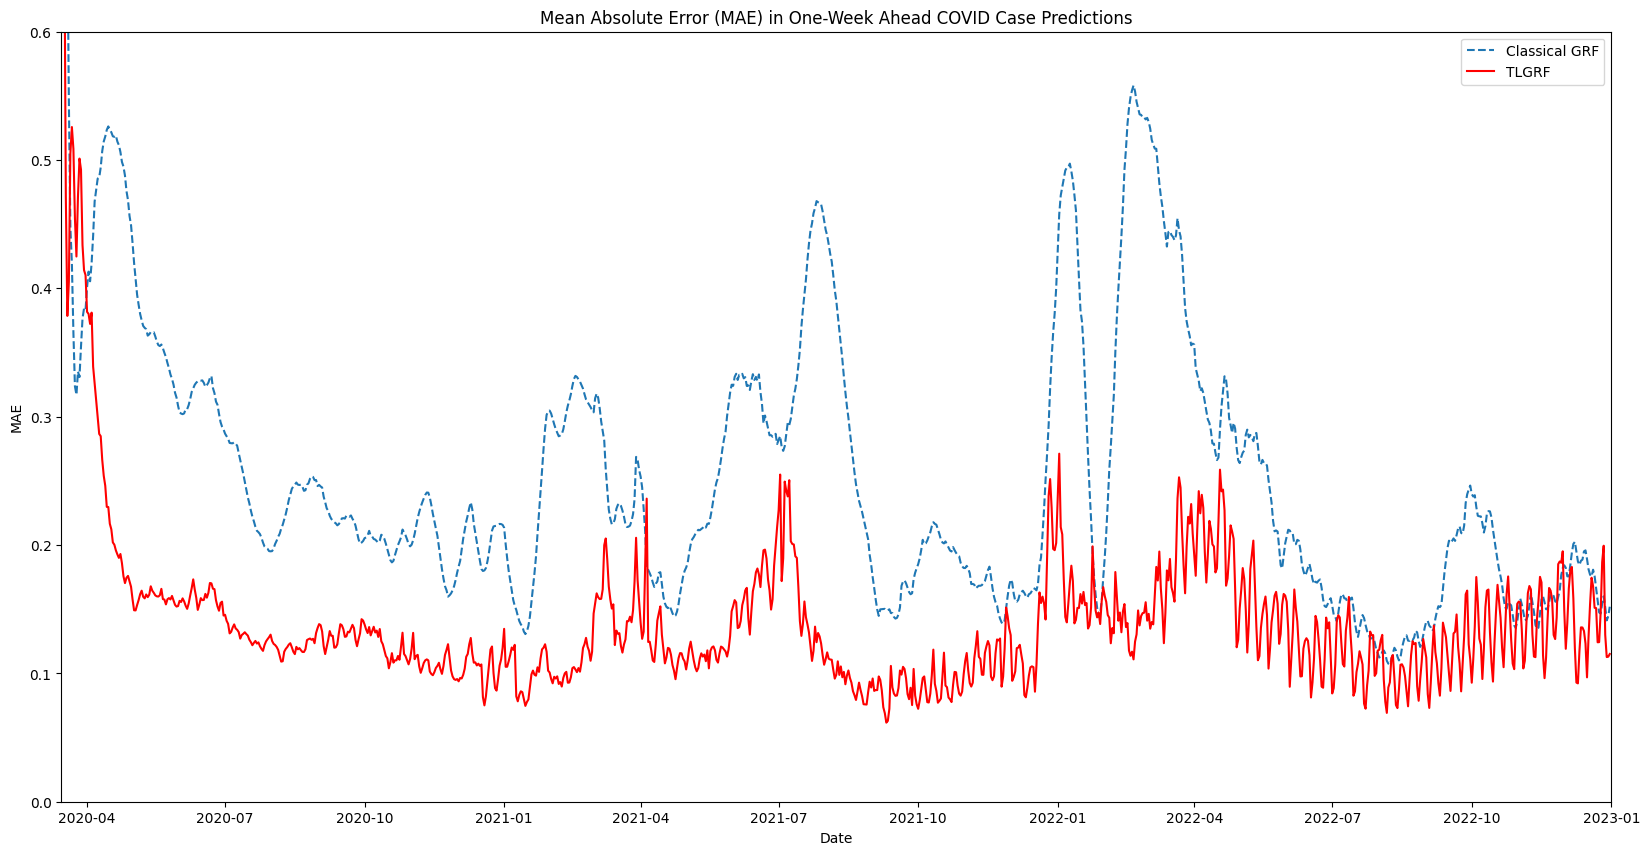

In [32]:
plt.figure(figsize=(20,10))

#plt.plot(tcv_performance_df["rmse"], label="tcv")
#plt.plot(ctcv_performance_df["rmse"], label="ctcv")
#plt.plot(RMSE_shifted_W_time_invariant_GRF_df, label="Time Invariant Shifted W GRF")
#plt.plot(RMSE_shifted_W_time_variant_GRF_df, label="Time Variant Shifted W GRF")
plt.plot(MAE_time_invariant_GRF_df, label="Classical GRF", linestyle="dashed")
#plt.plot(RMSE_time_variant_GRF_df, label="Time Variant GRF")
plt.plot(MAE_TLGRF, label="TLGRF", color="red")

plt.legend()
plt.xlabel("Date")
plt.ylabel("MAE")
plt.title("Mean Absolute Error (MAE) in One-Week Ahead COVID Case Predictions")
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))
plt.ylim(0,0.6)
plt.savefig("updated_grf_tlgrf_mae.png")
plt.show()

In [33]:
def check_gt(df1, df2):
    #print(df1.shape)
    #print(df2.shape)
    check_df = pd.merge(df1, df2, on=["fips","days_from_start"], how="inner")
    check_x = np.sum(check_df["log_rolled_cases_x"] - check_df["log_rolled_cases_y"])
    check_y = np.sum(check_df["shifted_log_rolled_cases_x"] - check_df["shifted_log_rolled_cases_y"])
    return (check_df, check_x, check_y)

In [34]:
RMSE_TLGRF.to_csv("RMSE_TLGRF.csv")
MAE_TLGRF.to_csv("MAE_TLGRF.csv")
RMSE_time_invariant_GRF_df.to_csv("RMSE_time_invariant_GRF_df.csv")
MAE_time_invariant_GRF_df.to_csv("MAE_time_invariant_GRF_df.csv")
RMSE_time_variant_GRF_df.to_csv("RMSE_time_variant_GRF_df.csv")
MAE_time_variant_GRF_df.to_csv("MAE_time_variant_GRF_df.csv")
RMSE_time_variant_no_CUSP_GRF_df.to_csv("RMSE_time_variant_no_CUSP_GRF_df.csv")
MAE_time_variant_no_CUSP_GRF_df.to_csv("MAE_time_variant_no_CUSP_GRF_df.csv")


RMSE_shifted_W_time_invariant_GRF_df.to_csv("RMSE_shifted_W_time_invariant_GRF_df.csv")
MAE_shifted_W_time_invariant_GRF_df.to_csv("MAE_shifted_W_time_invariant_GRF_df.csv")
RMSE_shifted_W_time_variant_GRF_df.to_csv("RMSE_shifted_W_time_variant_GRF_df.csv")
MAE_shifted_W_time_variant_GRF_df.to_csv("MAE_shifted_W_time_variant_GRF_df.csv")